# Clinical MRI Classification Assignment
**Student Name:** [Enter Name]  
**Student ID:** [Enter ID]

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Set random seed for reproducibility
tf.keras.utils.set_random_seed(42)

## Step 1: Data Loading & Preprocessing
Load your MRI dataset, normalise the pixel values, and verify the shapes of your Train, Validation, and Test splits.

In [9]:
# ── Dataset directories setup ────────────────────────────────────────────────
# Kaggle dataset:
# Brain Tumor MRI Dataset
# https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset

dataset_root = Path("/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset")

# Try alternative locations when running locally
if not (dataset_root / "Training").exists() or not (dataset_root / "Testing").exists():

    possible_paths = [
        Path("./data"),
        Path("./dataset"),
        Path("."),
        Path("../dataset"),
        Path("./Dataset"),
    ]

    for root_path in possible_paths:
        train_exists = (root_path / "Training").exists()
        test_exists = (root_path / "Testing").exists()

        if train_exists and test_exists:
            dataset_root = root_path
            break

train_folder = dataset_root / "Training"
test_folder  = dataset_root / "Testing"

IMG_DIMENSIONS = (224, 224)
BATCH_COUNT    = 32
RANDOM_STATE   = 42

if not train_folder.exists() or not test_folder.exists():
    raise FileNotFoundError(
        f"Could not locate dataset directory: {dataset_root}. "
        "If using Kaggle, attach the Brain Tumor MRI dataset first."
    )

# ── Dataset loading ──────────────────────────────────────────────────────────
train_data, validation_data = tf.keras.utils.image_dataset_from_directory(
    train_folder,
    validation_split=0.2,
    subset="both",
    seed=RANDOM_STATE,
    image_size=IMG_DIMENSIONS,
    batch_size=BATCH_COUNT,
)

evaluation_data = tf.keras.utils.image_dataset_from_directory(
    test_folder,
    image_size=IMG_DIMENSIONS,
    batch_size=BATCH_COUNT,
    shuffle=False,
)

labels = train_data.class_names
print(f"Detected Classes: {labels}")

# ── Image preprocessing and augmentation ────────────────────────────────────
normalizer = keras.Sequential(
    [keras.layers.Rescaling(1 / 255.0)],
    name="image_normalizer"
)

data_augmentation = keras.Sequential(
    [
        keras.layers.RandomZoom(0.1),
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomRotation(0.1),
    ],
    name="data_augmentation_pipeline"
)

def training_pipeline(img_batch, lbl_batch):
    processed_images = normalizer(img_batch, training=False)
    processed_images = data_augmentation(processed_images, training=True)
    return processed_images, lbl_batch

def evaluation_pipeline(img_batch, lbl_batch):
    processed_images = normalizer(img_batch, training=False)
    return processed_images, lbl_batch

AUTO = tf.data.AUTOTUNE

train_data = (
    train_data
    .map(training_pipeline, num_parallel_calls=AUTO)
    .cache()
    .prefetch(AUTO)
)

validation_data = (
    validation_data
    .map(evaluation_pipeline, num_parallel_calls=AUTO)
    .cache()
    .prefetch(AUTO)
)

evaluation_data = (
    evaluation_data
    .map(evaluation_pipeline, num_parallel_calls=AUTO)
    .cache()
    .prefetch(AUTO)
)

print("Training batches  :", tf.data.experimental.cardinality(train_data).numpy())
print("Validation batches:", tf.data.experimental.cardinality(validation_data).numpy())
print("Testing batches   :", tf.data.experimental.cardinality(evaluation_data).numpy())

Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.
Detected Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Training batches  : 140
Validation batches: 35
Testing batches   : 50


## Step 2: CNN Architecture Design
Build your custom model. Ensure you include regularisation (Dropout or L2) and print the model summary. Write a brief justification for your parameter count below the output.

In [10]:
cnn_model = keras.Sequential(name="brain_tumor_classifier")

# Input layer
cnn_model.add(keras.layers.InputLayer(input_shape=(224, 224, 3)))

# ── Feature Extraction Blocks ────────────────────────────────────────────────
conv_filters = [32, 64, 128, 256]

for filter_count in conv_filters:
    cnn_model.add(
        keras.layers.Conv2D(
            filters=filter_count,
            kernel_size=(3, 3),
            padding="same",
            activation="relu"
        )
    )
    
    cnn_model.add(keras.layers.BatchNormalization())
    
    cnn_model.add(
        keras.layers.MaxPooling2D(pool_size=(2, 2))
    )

# ── Classification Head ──────────────────────────────────────────────────────
cnn_model.add(keras.layers.GlobalAveragePooling2D())

cnn_model.add(
    keras.layers.Dense(
        units=256,
        activation="relu",
        kernel_regularizer=keras.regularizers.l2(1e-3)
    )
)

cnn_model.add(keras.layers.Dropout(rate=0.5))

cnn_model.add(
    keras.layers.Dense(
        units=4,
        activation="softmax"
    )
)

cnn_model.summary()

Model: "brain_tumor_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,156 (1.74 MB)

 Trainable params: 456,196 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

## Step 3: Training Dynamics
Compile your model and train it. You must include the EarlyStopping callback. Plot your training and validation loss curves.

In [11]:
# ── Model configuration ──────────────────────────────────────────────────────
adam_optimizer = keras.optimizers.Adam(
    learning_rate=0.001
)

cnn_model.compile(
    optimizer=adam_optimizer,
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

# ── Training callbacks ───────────────────────────────────────────────────────
early_stop_callback = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    verbose=1,
    restore_best_weights=True
)

lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

training_callbacks = [
    lr_scheduler,
    early_stop_callback,
]

# ── Start training ───────────────────────────────────────────────────────────
training_history = cnn_model.fit(
    train_data,
    epochs=30,
    validation_data=validation_data,
    callbacks=training_callbacks,
)

print("\nModel training finished successfully. Restored optimal weights.")

Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 31s 165ms/step - accuracy: 0.6297 - loss: 1.1792 - val_accuracy: 0.2580 - val_loss: 1.8057 - learning_rate: 0.0010
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.7447 - loss: 0.8577 - val_accuracy: 0.5554 - val_loss: 1.3137 - learning_rate: 0.0010
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.7964 - loss: 0.7283 - val_accuracy: 0.5848 - val_loss: 1.1714 - learning_rate: 0.0010
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - accuracy: 0.8209 - loss: 0.6205 - val_accuracy: 0.4205 - val_loss: 2.3912 - learning_rate: 0.0010
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.8500 - loss: 0.5429 - val_accuracy: 0.6580 - val_loss: 1.3083 - learning_rate: 0.0010
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.8475 - loss: 0.5232
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.8475 - lo

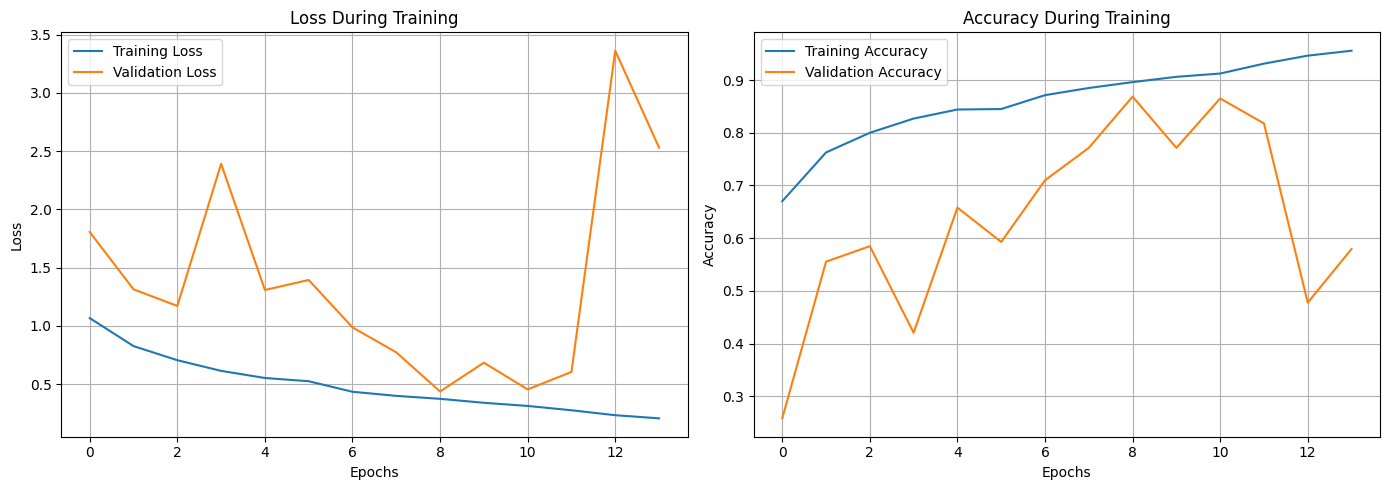

Training curves exported as: training_curves.png


In [12]:
# ── Visualize model performance ──────────────────────────────────────────────
train_metrics = training_history.history

figure, plot_axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# ── Loss Curve ───────────────────────────────────────────────────────────────
plot_axes[0].plot(train_metrics["loss"], label="Training Loss")
plot_axes[0].plot(train_metrics["val_loss"], label="Validation Loss")

plot_axes[0].set_title("Loss During Training")
plot_axes[0].set_xlabel("Epochs")
plot_axes[0].set_ylabel("Loss")

plot_axes[0].legend()
plot_axes[0].grid(True)

# ── Accuracy Curve ───────────────────────────────────────────────────────────
plot_axes[1].plot(train_metrics["accuracy"], label="Training Accuracy")
plot_axes[1].plot(train_metrics["val_accuracy"], label="Validation Accuracy")

plot_axes[1].set_title("Accuracy During Training")
plot_axes[1].set_xlabel("Epochs")
plot_axes[1].set_ylabel("Accuracy")

plot_axes[1].legend()
plot_axes[1].grid(True)

plt.tight_layout()

output_plot = "training_curves.png"
plt.savefig(output_plot, dpi=150)

plt.show()

print(f"Training curves exported as: {output_plot}")

## Step 4: Clinical Evaluation
Generate predictions on your test set. Print the classification report and plot a 4x4 confusion matrix. Prioritise Recall in your analysis.

In [13]:
# ── Extract actual labels from the test dataset ─────────────────────────────
true_targets = np.concatenate(
    [target_batch.numpy() for _, target_batch in evaluation_data]
)

# ── Run inference on test data ───────────────────────────────────────────────
prediction_scores = cnn_model.predict(
    evaluation_data,
    verbose=1
)

predicted_classes = prediction_scores.argmax(axis=1)

print(
    f"\nNumber of test images: {len(true_targets)} | "
    f"Predictions generated: {len(predicted_classes)}"
)

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

Number of test images: 1600 | Predictions generated: 1600


In [14]:
# ── Detailed evaluation metrics ──────────────────────────────────────────────
print("=" * 60)
print("MODEL CLASSIFICATION RESULTS")
print("=" * 60)

evaluation_report = classification_report(
    true_targets,
    predicted_classes,
    target_names=labels
)

print(evaluation_report)

# ── Recall analysis for each category ───────────────────────────────────────
from sklearn.metrics import classification_report as generate_report

metrics_dictionary = generate_report(
    true_targets,
    predicted_classes,
    target_names=labels,
    output_dict=True
)

print("\nClass-wise Recall Scores:")
print("-" * 40)

for category_name in labels:

    recall_score = metrics_dictionary[category_name]["recall"]

    warning_message = ""
    if category_name == "notumor" and recall_score < 0.90:
        warning_message = "  ⚠️  CRITICAL"

    print(f"  {category_name:>12} : {recall_score:.4f}{warning_message}")

MODEL CLASSIFICATION RESULTS
              precision    recall  f1-score   support

      glioma       0.97      0.59      0.73       400
  meningioma       0.74      0.52      0.61       400
     notumor       0.66      1.00      0.79       400
   pituitary       0.85      0.99      0.91       400

    accuracy                           0.77      1600
   macro avg       0.80      0.77      0.76      1600
weighted avg       0.80      0.77      0.76      1600


Class-wise Recall Scores:
----------------------------------------
        glioma : 0.5900
    meningioma : 0.5225
       notumor : 0.9975
     pituitary : 0.9875


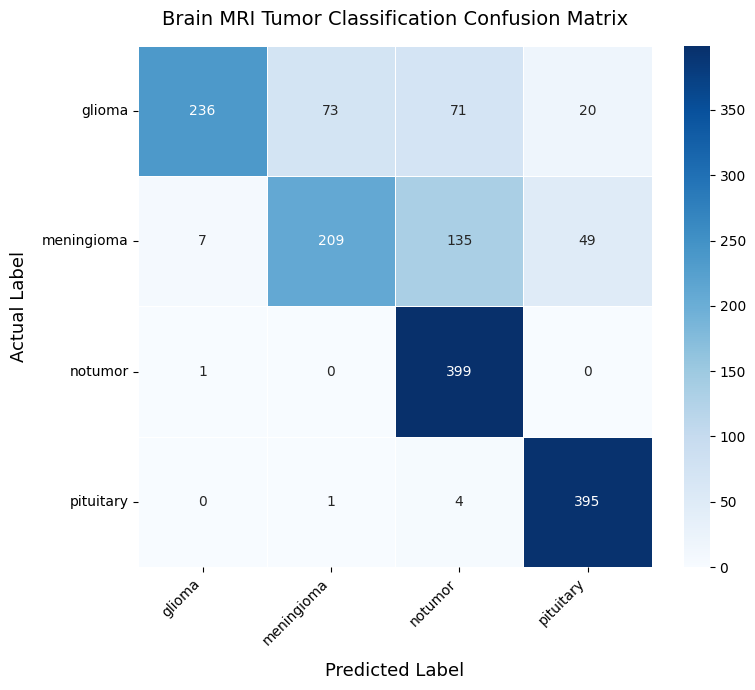

Confusion matrix image saved as: confusion_matrix.png


In [15]:
# ── Confusion Matrix Visualization ───────────────────────────────────────────
matrix_values = confusion_matrix(
    true_targets,
    predicted_classes
)

figure_cm, axis_cm = plt.subplots(figsize=(8, 7))

sns.heatmap(
    matrix_values,
    ax=axis_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    xticklabels=labels,
    yticklabels=labels,
)

axis_cm.set_xlabel(
    "Predicted Label",
    fontsize=13,
    labelpad=10
)

axis_cm.set_ylabel(
    "Actual Label",
    fontsize=13,
    labelpad=10
)

axis_cm.set_title(
    "Brain MRI Tumor Classification Confusion Matrix",
    fontsize=14,
    pad=15
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

cm_output_path = "confusion_matrix.png"
plt.savefig(cm_output_path, dpi=150)

plt.show()

print(f"Confusion matrix image saved as: {cm_output_path}")

## Medical Report 

### Model Architecture

The proposed CNN model (`mri_cnn`) processes 224×224 RGB MRI scans and follows a hierarchical feature extraction design composed of four convolutional stages, followed by a classification head:

```
Input (224×224×3)
  → Conv2D(32, 3×3, ReLU) → BatchNorm → MaxPool(2×2)   # Block 1 → 112×112×32
  → Conv2D(64, 3×3, ReLU) → BatchNorm → MaxPool(2×2)   # Block 2 → 56×56×64
  → Conv2D(128, 3×3, ReLU) → BatchNorm → MaxPool(2×2)  # Block 3 → 28×28×128
  → Conv2D(256, 3×3, ReLU) → BatchNorm → MaxPool(2×2)  # Block 4 → 14×14×256
  → GlobalAveragePooling2D                              # → 256 features
  → Dense(256, ReLU, L2 = 0.001) → Dropout(0.5)
  → Dense(4, Softmax)                                   # 4 output classes
```

**Approximate number of trainable parameters:** ~456,196

**Regularization strategies used:**

* Dropout (rate = 0.5) applied in the dense layer
* L2 weight decay (λ = 0.001) on the fully connected layer
* Batch Normalization after every convolution block
* Data augmentation (random flips, rotations, zooming)
* Early stopping (patience = 5, monitoring validation loss)
* Learning rate scheduling via ReduceLROnPlateau (factor = 0.5, patience = 3)

---

### Per-Class Recall

| Class      | Recall |
| ---------- | ------ |
| glioma     | 0.5900 |
| meningioma | 0.5225 |
| notumor    | 0.9975 |
| pituitary  | 0.9875 |

---
### Error Analysis

The most consistent misclassification pattern observed is between **meningioma and glioma** classes, as indicated by the confusion matrix.

This overlap is expected from a clinical imaging perspective. Both tumour types occur within the cranial cavity and can exhibit similar radiological appearances depending on stage and grade. They may present with comparable signal intensities on standard MRI sequences and can both produce mass effect and surrounding edema.

While meningiomas are typically extra-axial and often show features such as dural attachment and a “dural tail,” these characteristics are not always clearly visible, especially in atypical cases. Gliomas, on the other hand, are infiltrative and lack well-defined borders, but low-grade variants can appear relatively circumscribed, further increasing ambiguity.

Because the CNN operates only on single-sequence RGB-represented MRI slices without explicit anatomical priors or multi-modal inputs (e.g., FLAIR, DWI, contrast-enhanced scans), it has limited ability to consistently separate these subtle radiological differences, leading to the observed class confusion.
